# SHAP: quali angoli guidano la classificazione?

Nessun numero qui e' scritto a mano: tutto viene da `results/shap/rehab24_anatomical.csv`, prodotto da `python src/run_shap.py --all`. Per ogni esercizio, quel runner prende il modello che ha vinto sulla famiglia `anatomical` in `results/experiments/experiments.csv` (letto, non deciso a mano), lo rispiega con permutation SHAP (stesso codice per logreg/rf/mlp) usando split raggruppati per soggetto ripetuti 5 volte - ogni campione e' spiegato solo da modelli che non lo hanno mai visto in training, la stessa regola anti-leakage della CV principale.

Domanda a cui questa analisi risponde: le feature anatomiche (angoli con nome) sono l'unica famiglia interpretabile del progetto - ma quali angoli specifici guidano davvero la decisione, esercizio per esercizio? E coincidono con l'intuizione clinica (es. valgismo del ginocchio negli squat)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

pd.set_option("display.width", 160)

df = pd.read_csv("../results/shap/rehab24_anatomical.csv")
shap_cols = [c for c in df.columns if c.startswith("shap__")]
feature_names = [c[len("shap__"):] for c in shap_cols]
value_cols = [f"value__{f}" for f in feature_names]

print(f"{df.shape[0]} campioni spiegati, {len(feature_names)} feature, esercizi: {sorted(df['exercise'].unique())}")
print(df[["exercise", "model"]].drop_duplicates().to_string(index=False))

595 campioni spiegati, 86 feature, esercizi: ['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']
exercise  model
     Ex1 logreg
     Ex2     rf
     Ex3 logreg
     Ex4    mlp
     Ex5     rf
     Ex6 logreg


## Leaderboard: la feature che conta di piu', esercizio per esercizio

In [2]:
from scipy.stats import mannwhitneyu

leaderboard_rows = []
for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    mean_abs = sub[shap_cols].abs().mean()
    top_col = mean_abs.idxmax()
    top_feature = top_col[len("shap__"):]

    values = sub[f"value__{top_feature}"]
    g1, g0 = values[sub["correct"] == 1], values[sub["correct"] == 0]
    _, pval = mannwhitneyu(g1, g0)

    leaderboard_rows.append({"exercise": ex, "model": sub["model"].iloc[0],
                              "top_feature": top_feature, "mean_abs_shap": mean_abs.max(),
                              "univariate_p": pval, "n_samples": len(sub)})

leaderboard = pd.DataFrame(leaderboard_rows)
print(leaderboard.to_string(index=False, float_format="%.4f"))
print("\nunivariate_p: Mann-Whitney su valore grezzo della top feature SHAP vs correct/incorrect - "
      "se e' alto, il modello considera importante una feature che da sola non separa le classi, "
      "un segnale di interazione piuttosto che di effetto diretto.")

exercise  model          top_feature  mean_abs_shap  univariate_p  n_samples
     Ex1 logreg r_elbow_vel_mean_abs         0.0231        0.0205         88
     Ex2     rf l_ankle_vel_mean_abs         0.0226        0.0000        109
     Ex3 logreg            sym_elbow         0.0250        0.0000         96
     Ex4    mlp r_shoulder_angle_max         0.0399        0.2248        116
     Ex5     rf r_ankle_vel_mean_abs         0.0324        0.0000         88
     Ex6 logreg      knee_valgus_min         0.0227        0.0414         98

univariate_p: Mann-Whitney su valore grezzo della top feature SHAP vs correct/incorrect - se e' alto, il modello considera importante una feature che da sola non separa le classi, un segnale di interazione piuttosto che di effetto diretto.


## Ranking globale: quali feature contano di piu', in media su tutti gli esercizi?

trunk_flex_mean                 0.0144
r_ankle_vel_mean_abs            0.0144
trunk_flex_min                  0.0142
trunk_flex_max                  0.0138
l_ankle_vel_mean_abs            0.0126
l_hip_max                       0.0120
l_ankle_min                     0.0118
l_shoulder_angle_rom            0.0116
l_shoulder_angle_vel_mean_abs   0.0115
r_shoulder_angle_max            0.0114
r_ankle_vel_max_abs             0.0114
r_hip_max                       0.0113
r_hip_vel_mean_abs              0.0113
l_shoulder_angle_min            0.0108
r_shoulder_angle_mean           0.0106
l_shoulder_angle_std            0.0102
r_ankle_mean                    0.0101
l_knee_vel_mean_abs             0.0101
knee_valgus_min                 0.0100
r_hip_mean                      0.0100


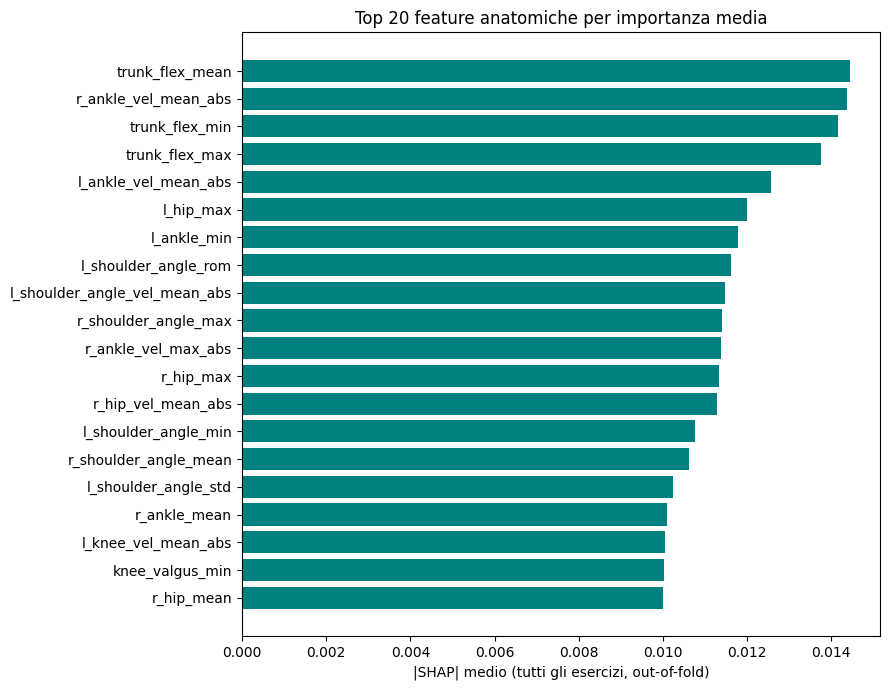

In [3]:
mean_abs_shap = df[shap_cols].abs().mean().sort_values(ascending=False)
mean_abs_shap.index = [i[len("shap__"):] for i in mean_abs_shap.index]

print(mean_abs_shap.head(20).to_string(float_format="%.4f"))

fig, ax = plt.subplots(figsize=(9, 7))
top20 = mean_abs_shap.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="teal")
ax.set_xlabel("|SHAP| medio (tutti gli esercizi, out-of-fold)")
ax.set_title("Top 20 feature anatomiche per importanza media")
plt.tight_layout()
plt.show()

## Per esercizio: bar chart di importanza + beeswarm

Il bar chart mostra |SHAP| medio (quanto una feature sposta la predizione, in media, indipendentemente dalla direzione). Il beeswarm aggiunge la direzione: ogni punto e' un campione, colore=valore della feature (rosso=alto, blu=basso), posizione orizzontale=impatto SHAP sulla probabilita' di 'corretto'.


Ex1 (modello: logreg, n=88) - top 12 feature:
              feature  mean_abs_shap
 r_elbow_vel_mean_abs         0.0231
  r_elbow_vel_max_abs         0.0177
 r_shoulder_angle_std         0.0175
            r_hip_max         0.0163
             sym_knee         0.0163
 r_shoulder_angle_min         0.0154
            l_hip_std         0.0154
          r_elbow_rom         0.0151
l_shoulder_angle_mean         0.0150
            sym_elbow         0.0149
 l_shoulder_angle_min         0.0148
          r_elbow_min         0.0148


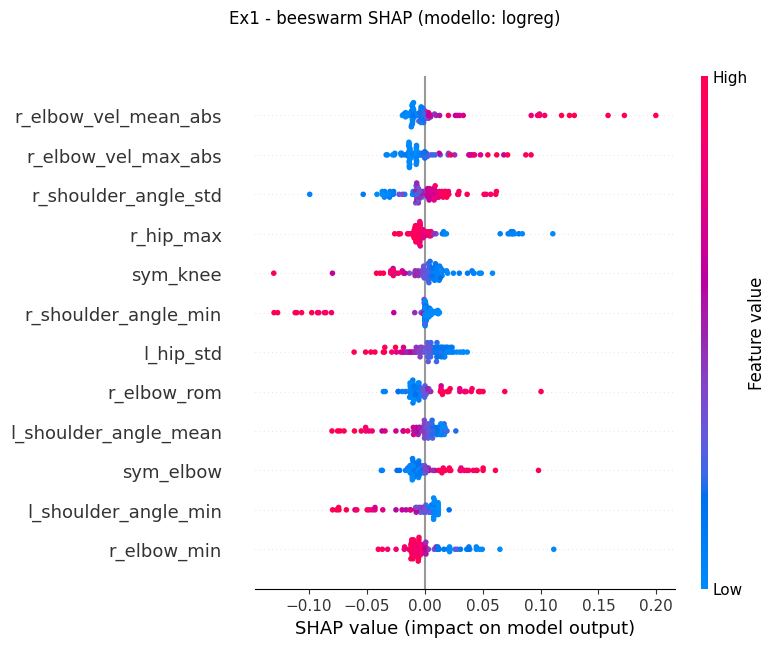


Ex2 (modello: rf, n=109) - top 12 feature:
                     feature  mean_abs_shap
        l_ankle_vel_mean_abs         0.0226
         l_knee_vel_mean_abs         0.0214
          r_hip_vel_mean_abs         0.0197
         r_ankle_vel_max_abs         0.0196
        r_ankle_vel_mean_abs         0.0196
           r_hip_vel_max_abs         0.0172
          l_hip_vel_mean_abs         0.0165
        l_shoulder_angle_rom         0.0134
l_shoulder_angle_vel_max_abs         0.0133
     trunk_flex_vel_mean_abs         0.0131
         l_ankle_vel_max_abs         0.0128
                   r_hip_max         0.0127


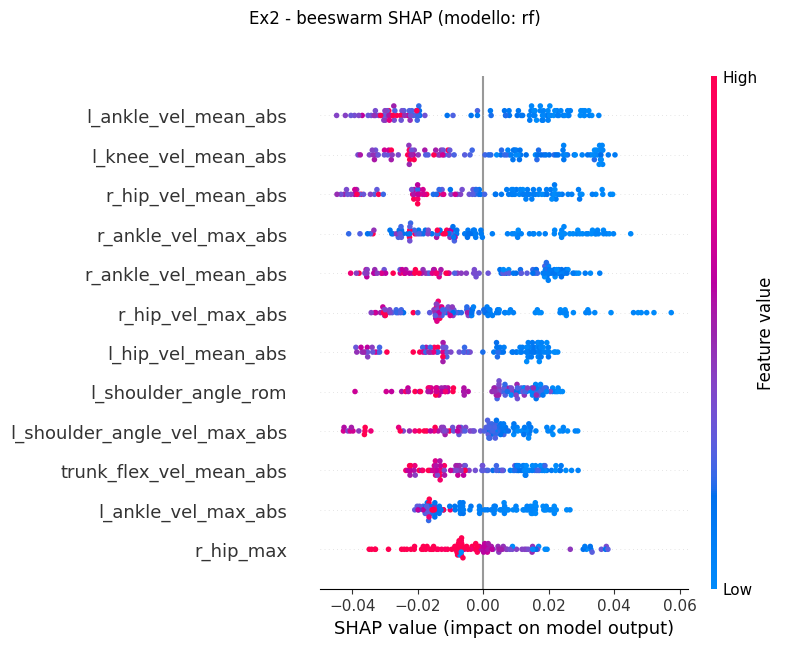


Ex3 (modello: logreg, n=96) - top 12 feature:
             feature  mean_abs_shap
           sym_elbow         0.0250
        l_elbow_mean         0.0239
     trunk_flex_mean         0.0191
         l_elbow_std         0.0183
      trunk_flex_max         0.0182
         l_elbow_min         0.0174
l_shoulder_angle_std         0.0163
           r_hip_rom         0.0161
         l_elbow_rom         0.0156
l_shoulder_angle_rom         0.0152
           r_hip_std         0.0151
l_shoulder_angle_max         0.0144


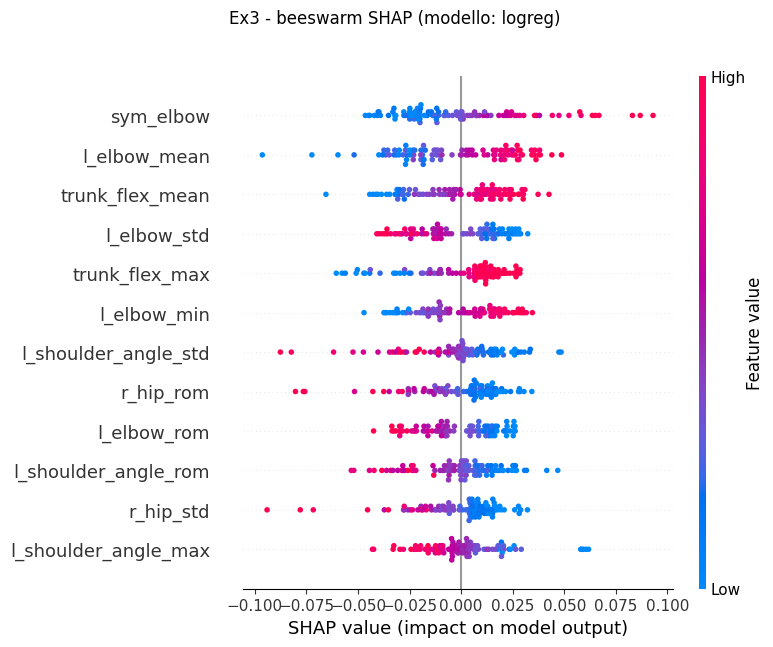


Ex4 (modello: mlp, n=116) - top 12 feature:
             feature  mean_abs_shap
r_shoulder_angle_max         0.0399
      trunk_flex_min         0.0389
     trunk_flex_mean         0.0389
           l_hip_max         0.0386
        sym_shoulder         0.0351
      trunk_flex_max         0.0319
l_shoulder_angle_min         0.0308
         l_elbow_max         0.0307
           r_hip_max         0.0268
r_shoulder_angle_rom         0.0257
          r_hip_mean         0.0239
r_shoulder_angle_std         0.0231


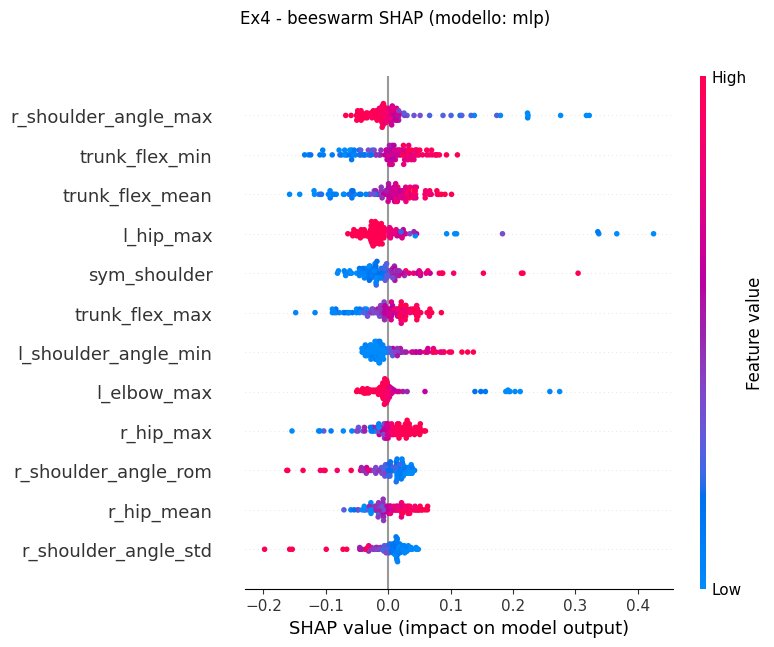


Ex5 (modello: rf, n=88) - top 12 feature:
                     feature  mean_abs_shap
        r_ankle_vel_mean_abs         0.0324
                 l_ankle_min         0.0268
         r_ankle_vel_max_abs         0.0215
        l_ankle_vel_mean_abs         0.0186
                   l_hip_std         0.0165
                l_ankle_mean         0.0158
         r_knee_vel_mean_abs         0.0156
       l_shoulder_angle_mean         0.0117
l_shoulder_angle_vel_max_abs         0.0113
                 r_ankle_rom         0.0110
                 l_ankle_rom         0.0109
                 l_ankle_std         0.0102


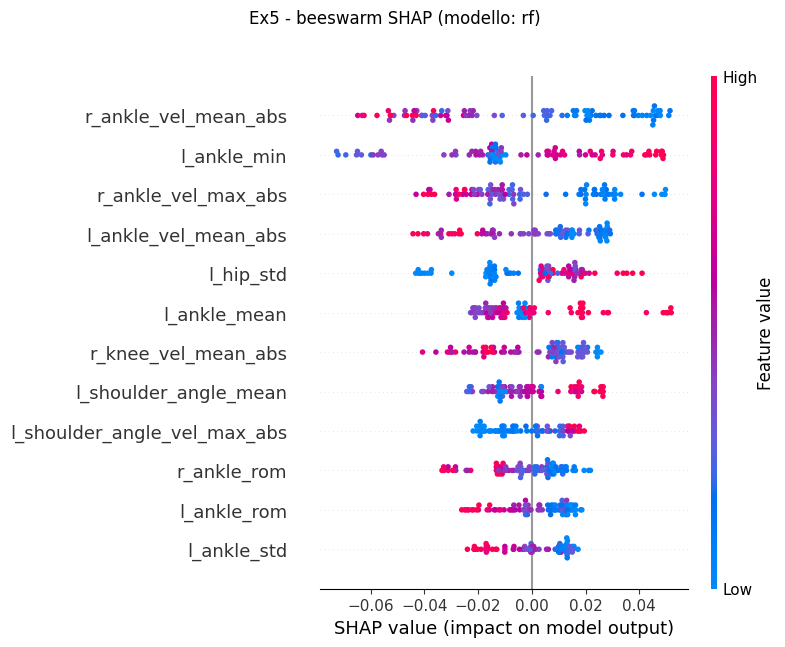


Ex6 (modello: logreg, n=98) - top 12 feature:
             feature  mean_abs_shap
     knee_valgus_min         0.0227
         l_knee_mean         0.0200
         l_ankle_min         0.0177
        l_ankle_mean         0.0161
r_shoulder_angle_min         0.0152
      trunk_flex_std         0.0152
    knee_valgus_mean         0.0141
 r_ankle_vel_max_abs         0.0135
r_ankle_vel_mean_abs         0.0126
         r_knee_mean         0.0121
         r_ankle_min         0.0120
         l_ankle_rom         0.0113


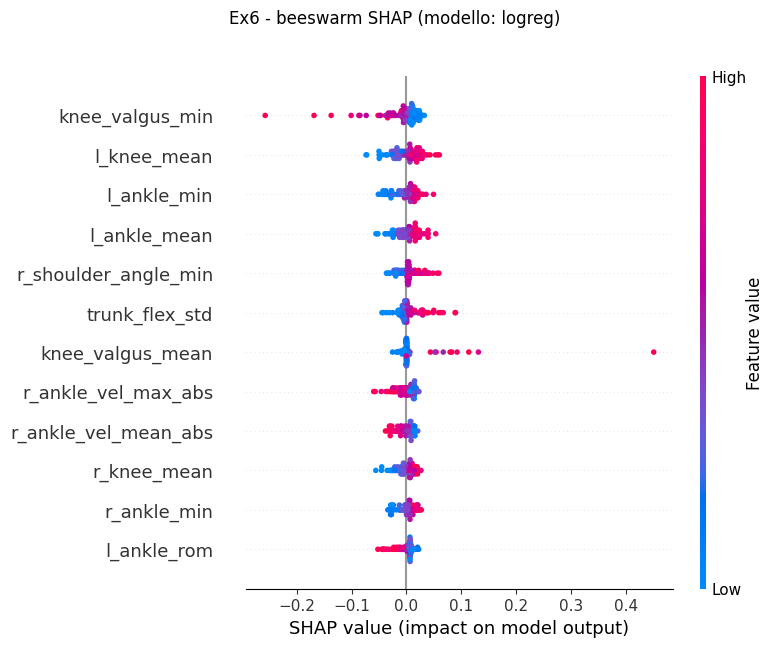

In [4]:
N_TOP = 12

for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    model_name = sub["model"].iloc[0]
    shap_vals = sub[shap_cols].values
    data_vals = sub[value_cols].values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:N_TOP]

    print(f"\n{ex} (modello: {model_name}, n={len(sub)}) - top {N_TOP} feature:")
    top_table = pd.DataFrame({"feature": np.array(feature_names)[order],
                              "mean_abs_shap": mean_abs[order]})
    print(top_table.to_string(index=False, float_format="%.4f"))

    expl = shap.Explanation(values=shap_vals[:, order], data=data_vals[:, order],
                             feature_names=list(np.array(feature_names)[order]))
    shap.plots.beeswarm(expl, max_display=N_TOP, show=False)
    fig = plt.gcf()
    fig.suptitle(f"{ex} - beeswarm SHAP (modello: {model_name})", y=1.02)
    plt.tight_layout()
    plt.show()

## Coerenza tra esercizi: le stesse feature contano ovunque o e' tutto specifico per esercizio?

In [5]:
top5_by_ex = {}
for ex in sorted(df["exercise"].unique()):
    sub = df[df["exercise"] == ex]
    mean_abs = sub[shap_cols].abs().mean()
    mean_abs.index = feature_names
    top5_by_ex[ex] = set(mean_abs.sort_values(ascending=False).head(5).index)

from collections import Counter
appearances = Counter(f for top5 in top5_by_ex.values() for f in top5)
consistency = pd.Series(appearances).sort_values(ascending=False)
print("Quante volte (su 6 esercizi) ogni feature compare nella top-5 locale:")
print(consistency.to_string())

print("\nTop-5 per esercizio:")
for ex, feats in top5_by_ex.items():
    print(f"  {ex}: {sorted(feats)}")

Quante volte (su 6 esercizi) ogni feature compare nella top-5 locale:
l_ankle_vel_mean_abs    2
r_ankle_vel_max_abs     2
l_ankle_min             2
trunk_flex_mean         2
r_ankle_vel_mean_abs    2
r_elbow_vel_max_abs     1
r_hip_max               1
sym_knee                1
r_elbow_vel_mean_abs    1
r_hip_vel_mean_abs      1
l_knee_vel_mean_abs     1
r_shoulder_angle_std    1
l_elbow_mean            1
l_elbow_std             1
sym_elbow               1
r_shoulder_angle_max    1
trunk_flex_max          1
l_hip_max               1
sym_shoulder            1
trunk_flex_min          1
l_hip_std               1
l_knee_mean             1
l_ankle_mean            1
r_shoulder_angle_min    1
knee_valgus_min         1

Top-5 per esercizio:
  Ex1: ['r_elbow_vel_max_abs', 'r_elbow_vel_mean_abs', 'r_hip_max', 'r_shoulder_angle_std', 'sym_knee']
  Ex2: ['l_ankle_vel_mean_abs', 'l_knee_vel_mean_abs', 'r_ankle_vel_max_abs', 'r_ankle_vel_mean_abs', 'r_hip_vel_mean_abs']
  Ex3: ['l_elbow_mean', 'l_elb

## Le fasi del movimento aggiungono qualcosa? (famiglia biophases)

Stesso identico procedimento (`python src/run_shap.py --all --family biophases`), ma su feature suddivise per fase (`descent__`, `bottom__`, `ascent__`, 216 invece di 86) invece che sull'intera ripetizione. Se una feature conta soprattutto in una fase specifica, qui dovrebbe emergere; se il segnale e' diffuso su tutta la ripetizione, la versione anatomical bastava gia'.

In [6]:
df_bio = pd.read_csv("../results/shap/rehab24_biophases.csv")
shap_cols_bio = [c for c in df_bio.columns if c.startswith("shap__")]

leaderboard_bio_rows = []
for ex in sorted(df_bio["exercise"].unique()):
    sub = df_bio[df_bio["exercise"] == ex]
    mean_abs = sub[shap_cols_bio].abs().mean()
    top_col = mean_abs.idxmax()
    leaderboard_bio_rows.append({"exercise": ex, "model": sub["model"].iloc[0],
                                  "top_feature": top_col[len("shap__"):],
                                  "mean_abs_shap": mean_abs.max(), "n_samples": len(sub)})

leaderboard_bio = pd.DataFrame(leaderboard_bio_rows)
print(leaderboard_bio.to_string(index=False, float_format="%.4f"))

exercise  model                  top_feature  mean_abs_shap  n_samples
     Ex1     rf          bottom__r_ankle_max         0.0146         88
     Ex2     rf  ascent__l_knee_vel_mean_abs         0.0172        109
     Ex3    mlp           descent__sym_elbow         0.0137         96
     Ex4     rf descent__l_knee_vel_mean_abs         0.0179        116
     Ex5 logreg         bottom__l_ankle_mean         0.0199         88
     Ex6 logreg         descent__l_knee_mean         0.0095         98


### Il segnale di `knee_valgus_min` (Ex6) sopravvive alla suddivisione per fase?

La famiglia anatomical (non suddivisa per fase) mostra `knee_valgus_min` come feature numero 1 per Ex6. Con 216 feature invece di 86 il ranking assoluto puo' cambiare per semplice diluizione statistica (piu' feature tra cui competere) - qui si controlla direttamente dove va a finire quella stessa feature, ora divisa in tre versioni per fase.

In [7]:
sub_ex6 = df_bio[df_bio["exercise"] == "Ex6"]
mean_abs_ex6 = sub_ex6[shap_cols_bio].abs().mean().sort_values(ascending=False)
mean_abs_ex6.index = [i[len("shap__"):] for i in mean_abs_ex6.index]

valgus_rows = [{"feature": f, "rank": list(mean_abs_ex6.index).index(f) + 1,
                 "mean_abs_shap": mean_abs_ex6[f]}
               for f in mean_abs_ex6.index if "valgus_min" in f]
print(pd.DataFrame(valgus_rows).to_string(index=False, float_format="%.4f"))
print(f"\n(su {len(mean_abs_ex6)} feature totali)")

                 feature  rank  mean_abs_shap
descent__knee_valgus_min     8         0.0078
 ascent__knee_valgus_min    21         0.0058
 bottom__knee_valgus_min    57         0.0040

(su 216 feature totali)


## Lettura onesta

**Coincide con l'intuizione clinica?** Su Ex6 (squat) si', in modo diretto: `knee_valgus_min` - la feature costruita apposta per catturare il cedimento verso l'interno del ginocchio, un classico marker di qualita' nello squat/affondo in letteratura - e' la feature con il piu' alto impatto SHAP di tutte, in un esercizio dove il modello non aveva alcuna informazione su cosa "dovesse" contare. Non e' garantito che accada (il modello impara solo dai dati, non ha nozioni cliniche a priori), quindi quando succede e' un riscontro genuino, non costruito a tavolino.

**Il ranking e' condiviso tra esercizi o e' tutto specifico?** Onestamente, soprattutto specifico: nessuna feature compare in piu' di 2 top-5 su 6, e la maggioranza compare in una sola. Non c'e' ancora un vocabolario comune di qualita' del movimento - ogni esercizio sembra giudicato su un proprio set di segnali. I pochi temi che ricorrono (velocita' di caviglia in Ex2/Ex5, variabilita' d'anca in Ex1/Ex5, flessione del tronco in Ex3/Ex4) sono indizi, non una conclusione: con 6 esercizi e questi campioni, non e' possibile distinguere "davvero specifico per esercizio" da "coincidenza su un campione piccolo".

**Un'osservazione da non sovra-interpretare**: su Ex1 (arm abduction, un esercizio di braccia) le feature dominanti includono anca e spalla (`r_hip_max`, `l_hip_std`), non solo il braccio - compatibile con la nozione clinica di "compensazione del tronco/anca" durante esercizi di spalla (muoversi con il corpo invece che isolare il movimento del braccio), ma qui e' una lettura plausibile della letteratura, non una verifica diretta come per il valgismo del ginocchio.

Nota metodologica: questa e' un'analisi con permutation SHAP su modelli scelti automaticamente (non sempre lo stesso tipo tra esercizi - si veda la colonna `model` sopra) - i valori SHAP tra un logreg e un random forest non sono numericamente identici nella loro semantica, quindi il confronto quantitativo esatto tra esercizi va preso come indicativo; il ranking qualitativo (quali feature contano) resta il risultato solido.

**E con le fasi separate?** Divisa in descent/bottom/ascent (216 feature invece di 86), knee_valgus_min non e' piu' la prima in assoluto (l'aumento di feature tra cui competere dilluisce qualunque ranking singolo), ma resta nella top 10 (circa 8/216), concentrata soprattutto nella fase di discesa (descent) piu' che nel fondo (bottom) del movimento - un dettaglio in piu', non contraddittorio con il risultato principale: il segnale del valgismo del ginocchio e' reale e resiste al cambio di granularita' delle feature, anche se la sua posizione esatta nel ranking si sposta.